<div align="center">
    <img src="https://sharif.edu/~salarieh/Sharif-Logo.jpg" width="150"/><br>
    <font size="7" color="#2566EE">Speech Processing</font><br>
    <font size="5" color="#0F8E9E">CE Department<br>Fall 2025 – Prof. Sameti</font><br>
</div>

# Practical Assignment 1: Fine-tuning SpeechT5 for Persian TTS

---

## Introduction

In this notebook, you will fine-tune **Microsoft SpeechT5** for **Persian Text-to-Speech (TTS)**. SpeechT5 is a transformer-based model that predicts acoustic features (mel-spectrograms) from input text, and a **HiFi-GAN vocoder** is used to convert these spectrograms into audible speech waveforms.

You will work with a Persian TTS dataset containing paired **text transcripts** and **audio recordings**. The notebook covers the full pipeline required for training and evaluation, including:
- Installing and verifying required dependencies.
- Loading the dataset and casting audio to a consistent sampling rate.
- Cleaning and normalizing text, and extending the tokenizer vocabulary for missing characters.
- Extracting **speaker embeddings (x-vectors)** using a pretrained **SpeechBrain** speaker recognition model.
- Preparing inputs/labels with proper padding and length filtering.
- Fine-tuning SpeechT5 using the Hugging Face `Seq2SeqTrainer`.
- Running inference on test samples and listening to synthesized outputs.

Please read the instructions in each section carefully and make sure your code is well-documented and reproducible.


# Install Requirements




In [1]:
!pip install --no-cache-dir "torchcodec==0.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.1 MB/s eta 0:00:00


In [2]:
# Install necessary libraries

!pip install transformers
!pip install datasets
!pip install soundfile
!pip install speechbrain
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.1/864.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 31.6 MB/s eta 0:00:00


In [3]:
import sys, torch
import importlib.metadata as md

print("python:", sys.version)
print("torch:", torch.__version__)
print("datasets:", md.version("datasets"))
print("torchcodec:", md.version("torchcodec"))

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.8.0+cu126
datasets: 4.0.0
torchcodec: 0.7.0


# Import Libraries

In [4]:
# Imports

import os
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Any, Dict, List, Union
from dataclasses import dataclass
from IPython.display import Audio as IPyAudio
import torch

from datasets import load_dataset, DatasetDict, Audio
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from speechbrain.pretrained import EncoderClassifier
device = "cuda" if torch.cuda.is_available() else "cpu"

/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _speechbrain_save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for _speechbrain_load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _save
DEBUG:speechbrain.utils.checkpoi

# Load Model

In [5]:
!nvidia-smi

Tue Jan 27 04:37:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# Load a pretrained processor and model
processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/585M [00:00<?, ?B/s]

SpeechT5ForTextToSpeech(
  (speecht5): SpeechT5Model(
    (encoder): SpeechT5EncoderWithTextPrenet(
      (prenet): SpeechT5TextEncoderPrenet(
        (embed_tokens): Embedding(81, 768, padding_idx=1)
        (encode_positions): SpeechT5ScaledPositionalEncoding(
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (wrapped_encoder): SpeechT5Encoder(
        (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0-11): 12 x SpeechT5EncoderLayer(
            (attention): SpeechT5Attention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (dropout): Dropout(p=0.1, inplace=False)
     

In [7]:
model

SpeechT5ForTextToSpeech(
  (speecht5): SpeechT5Model(
    (encoder): SpeechT5EncoderWithTextPrenet(
      (prenet): SpeechT5TextEncoderPrenet(
        (embed_tokens): Embedding(81, 768, padding_idx=1)
        (encode_positions): SpeechT5ScaledPositionalEncoding(
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (wrapped_encoder): SpeechT5Encoder(
        (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0-11): 12 x SpeechT5EncoderLayer(
            (attention): SpeechT5Attention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (dropout): Dropout(p=0.1, inplace=False)
     

In [8]:
processor

SpeechT5Processor:
- feature_extractor: SpeechT5FeatureExtractor {
  "do_normalize": false,
  "feature_extractor_type": "SpeechT5FeatureExtractor",
  "feature_size": 1,
  "fmax": 7600,
  "fmin": 80,
  "frame_signal_scale": 1.0,
  "hop_length": 16,
  "mel_floor": 1e-10,
  "num_mel_bins": 80,
  "padding_side": "right",
  "padding_value": 0.0,
  "processor_class": "SpeechT5Processor",
  "reduction_factor": 2,
  "return_attention_mask": true,
  "sampling_rate": 16000,
  "win_function": "hann_window",
  "win_length": 64
}

- tokenizer: SpeechT5Tokenizer(name_or_path='microsoft/speecht5_tts', vocab_size=79, model_max_length=600, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad

# Load Dataset

In [9]:
# Load your TTS dataset
dataset = load_dataset("mohammadhossein/SP_HW5_PersianTTS", split="train")
dataset = dataset.remove_columns(["text"])
# Cast the 'audio' column to the Audio format with a specific sampling rate
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print(dataset)

README.md:   0%|          | 0.00/538 [00:00<?, ?B/s]

data/train-00000-of-00010.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

data/train-00001-of-00010.parquet:   0%|          | 0.00/460M [00:00<?, ?B/s]

data/train-00002-of-00010.parquet:   0%|          | 0.00/439M [00:00<?, ?B/s]

data/train-00003-of-00010.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

...

data/val-00001-of-00003.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

data/val-00002-of-00003.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/41604 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/10559 [00:00<?, ? examples/s]

Dataset({
    features: ['client_id', 'audio', 'sentence'],
    num_rows: 41604
})


In [10]:
# Displaying the structure of the merged dataset
dataset_structure = dataset.features
dataset_structure

{'client_id': Value('string'),
 'audio': Audio(sampling_rate=16000, decode=True, stream_index=None),
 'sentence': Value('string')}

# Tokenizer Cleaning and Extension
In this section, we analyze the dataset to identify characters that are missing from the tokenizer vocabulary, normalize certain characters, and then extend the tokenizer to
fully support all characters present in the training data.

In [11]:
# (Do this BEFORE any remove_columns that might delete it)
text_col = None
if "sentence" in dataset.column_names:
    text_col = "sentence"
elif "text" in dataset.column_names:
    text_col = "text"
else:
    raise ValueError(f"Couldn't find a text column. Columns: {dataset.column_names}")

# Normalize to "sentence" so the rest of your code works
if text_col != "sentence":
    dataset = dataset.rename_column(text_col, "sentence")

# TODO : get the tokenizer from the processor
tokenizer = processor.tokenizer

In [12]:
# TODO : Define a function to extract all unique characters from a batch of sentences
def extract_all_chars(batch):
    # Return per-example unique chars so datasets.map(batched=True) is happy
    return {"chars": [list(set(s)) for s in batch["sentence"]]}


# TODO : Use the 'map' function to apply the 'extract_all_chars' function to the dataset
vocabs = dataset.map(extract_all_chars, batched=True, batch_size=1000)

# TODO : Get the unique characters from the extracted vocab
dataset_vocab = set()
for ch_list in vocabs["chars"]:
    dataset_vocab.update(ch_list)

# TODO : Get the unique characters from the tokenizer's vocabulary
# Tokenizer vocab entries are tokens/subwords; extract the *characters* appearing inside them
tokenizer_vocab = set()
for tok in tokenizer.get_vocab().keys():
    tokenizer_vocab.update(list(tok))

# The dataset vocabulary is now fully covered by the tokenizer vocabulary
print("Missing chars BEFORE cleanup:", sorted(dataset_vocab - tokenizer_vocab))


Map:   0%|          | 0/41604 [00:00<?, ? examples/s]

Missing chars BEFORE cleanup: [' ', '«', '»', '،', '؛', '؟', 'ء', 'آ', 'أ', 'ؤ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ـ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ً', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', 'ٔ', 'پ', 'چ', 'ژ', 'ک', 'گ', 'ۀ', 'ی', '–', '“', '”', '…', 'ﮩ', 'ﺁ']


In [13]:
# --- Your cleanup step ---
replacements = [
    ('š', 'ش'),
    ('ā', 'آ'),
]

def cleanup_text(inputs):
    for src, dst in replacements:
        inputs["sentence"] = inputs["sentence"].replace(src, dst)
    return inputs

dataset = dataset.map(cleanup_text)

# Recompute missing after cleanup (recommended)
vocabs = dataset.map(extract_all_chars, batched=True, batch_size=1000)

dataset_vocab = set()
for ch_list in vocabs["chars"]:
    dataset_vocab.update(ch_list)

# TODO : compute the set of dataset characters missing from the tokenizer
persian_char = dataset_vocab - tokenizer_vocab
print("Missing chars AFTER cleanup:", sorted(persian_char))


# TODO : Extend the tokenizer's vocabulary
# Add only the missing characters (as individual tokens)
new_tokens = sorted(persian_char)
num_added = tokenizer.add_tokens(new_tokens)
print("Num tokens added:", num_added)

# IMPORTANT: resize model embeddings after adding tokens
if num_added > 0:
    model.resize_token_embeddings(len(tokenizer))

# Verify that the new characters are added to the vocabulary
updated_vocab = processor.tokenizer.get_vocab()

# Verify coverage again
tokenizer_vocab_updated = set()
for tok in updated_vocab.keys():
    tokenizer_vocab_updated.update(list(tok))

print("Still missing after adding:", sorted(dataset_vocab - tokenizer_vocab_updated))
print("Tokenizer size now:", len(updated_vocab))

Map:   0%|          | 0/41604 [00:00<?, ? examples/s]

Map:   0%|          | 0/41604 [00:00<?, ? examples/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Missing chars AFTER cleanup: [' ', '«', '»', '،', '؛', '؟', 'ء', 'آ', 'أ', 'ؤ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ـ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ً', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', 'ٔ', 'پ', 'چ', 'ژ', 'ک', 'گ', 'ۀ', 'ی', '–', '“', '”', '…', 'ﮩ', 'ﺁ']
Num tokens added: 62
Still missing after adding: []
Tokenizer size now: 143


# Speaker define
This section analyzes the number of examples per speaker, visualizes their distribution, and reports the total number of unique speakers and samples in the dataset.

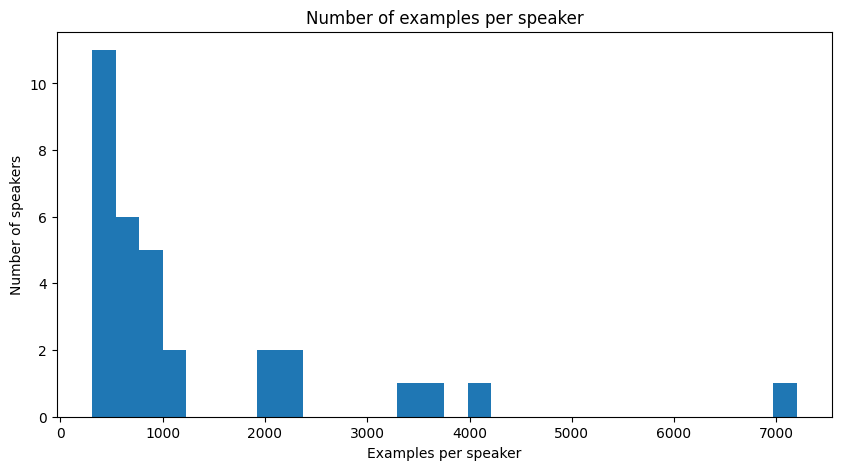

Speakers: 32
Samples: 41604
Min/Max/Avg examples per speaker: 310 7199 1300.125


In [14]:
from collections import defaultdict
import matplotlib.pyplot as plt

# create a dictionary to count the number of samples per speaker
speaker_counts = defaultdict(int)

# iterate over dataset and update the speaker counts
for spk in dataset["client_id"]:
    speaker_counts[spk] += 1

# plot a histogram of the number of examples per speaker
counts = list(speaker_counts.values())

plt.figure(figsize=(10, 5))
plt.hist(counts, bins=30)
plt.title("Number of examples per speaker")
plt.xlabel("Examples per speaker")
plt.ylabel("Number of speakers")
plt.show()

print("Speakers:", len(speaker_counts))
print("Samples:", len(dataset))
print("Min/Max/Avg examples per speaker:", min(counts), max(counts), sum(counts)/len(counts))


In [15]:
len(set(dataset["client_id"]))

32

In [16]:
len(dataset)

41604

# Speaker Embedding
This section loads a pretrained speaker recognition model and uses it to extract normalized speaker embeddings from raw audio waveforms.

In [17]:
# Load a pretrained speaker recognition model from SpeechBrain
# 'spk_model_name' should be the name of the desired speaker recognition model
speaker_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    run_opts={"device": device},
    savedir=os.path.join("/tmp", "speechbrain/spkrec-xvect-voxceleb")
)

# TODO : Define a function to create speaker embeddings from a given waveform
def create_speaker_embedding(waveform):
    """
    Create a speaker embedding from a waveform.

    Args:
        waveform: Can be
          - torch.Tensor of shape [T], [1,T], or [B,1,T]
          - numpy array of shape [T] or [1,T]

    Returns:
        torch.Tensor: embedding of shape [D] (1D)
    """
    import torch

    # Convert to torch tensor
    if not torch.is_tensor(waveform):
        waveform = torch.tensor(waveform, dtype=torch.float32)

    # Ensure shape is [B, T]
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)          # [1, T]
    elif waveform.ndim == 2:
        # could be [1, T] already; if [B, T] keep it
        pass
    elif waveform.ndim == 3:
        # if [B, 1, T] -> [B, T]
        if waveform.shape[1] == 1:
            waveform = waveform.squeeze(1)
        else:
            raise ValueError(f"Unexpected waveform shape: {tuple(waveform.shape)}")
    else:
        raise ValueError(f"Unexpected waveform ndim: {waveform.ndim}")

    waveform = waveform.to(device)

    with torch.no_grad():
        # SpeechBrain returns embeddings of shape [B, D]
        emb = speaker_model.encode_batch(waveform)
        emb = emb.squeeze(0)  # [D] if B==1

        # L2 normalize (common for cosine similarity / stable clustering)
        emb = torch.nn.functional.normalize(emb, p=2, dim=-1)

    return emb.cpu()


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached


hyperparams.yaml: 0.00B [00:00, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-xvect-voxceleb/snapshots/56895a2df401be4150a159f3a1c653f00051d477/hyperparams.yaml' -> '/tmp/speechbrain/spkrec-xvect-voxceleb/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for _load
DEBUG:speechbrain.utils.checkpoints:Registered parameter transfer hook for _load
/usr/local/lib/python3.12/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook fo

embedding_model.ckpt:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-xvect-voxceleb/snapshots/56895a2df401be4150a159f3a1c653f00051d477/embedding_model.ckpt' -> '/tmp/speechbrain/spkrec-xvect-voxceleb/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /tmp/speechbrain/spkrec-xvect-voxceleb/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached


...

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-xvect-voxceleb/snapshots/56895a2df401be4150a159f3a1c653f00051d477/mean_var_norm_emb.ckpt' -> '/tmp/speechbrain/spkrec-xvect-voxceleb/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /tmp/speechbrain/spkrec-xvect-voxceleb/mean_var_norm_emb.ckpt
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached


classifier.ckpt:   0%|          | 0.00/15.9M [00:00<?, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-xvect-voxceleb/snapshots/56895a2df401be4150a159f3a1c653f00051d477/classifier.ckpt' -> '/tmp/speechbrain/spkrec-xvect-voxceleb/classifier.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["classifier"] = /tmp/speechbrain/spkrec-xvect-voxceleb/classifier.ckpt
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached


label_encoder.txt: 0.00B [00:00, ?B/s]

DEBUG:speechbrain.utils.fetching:Fetch: Local file found, creating symlink '/root/.cache/huggingface/hub/models--speechbrain--spkrec-xvect-voxceleb/snapshots/56895a2df401be4150a159f3a1c653f00051d477/label_encoder.txt' -> '/tmp/speechbrain/spkrec-xvect-voxceleb/label_encoder.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["label_encoder"] = /tmp/speechbrain/spkrec-xvect-voxceleb/label_encoder.ckpt
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): embedding_model -> /tmp/speechbrain/spkrec-xvect-voxceleb/embedding_model.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): mean_var_norm_emb -> /tmp/speechbrain/spkrec-xvect-voxceleb/mean_var_norm_emb.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): classifier -> /tmp/speechbra

# Dataset Preparation and Filtering
This section preprocesses each sample by extracting text and audio features, generating speaker embeddings, and preparing model inputs, then filters the dataset to remove samples that exceed text or speech length constraints imposed by the model.

Processed keys: dict_keys(['input_ids', 'attention_mask', 'labels', 'speaker_embeddings'])
Decoded text: ن ه ،   ا و ن   چ ي ز   ق ش ن گ ي   ه س ت


/tmp/ipython-input-875642501.py:42: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  plt.imshow(torch.tensor(processed_example["labels"]).T)


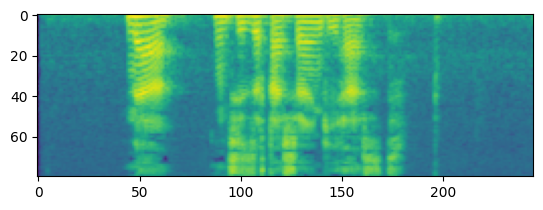

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/50.6M [00:00<?, ?B/s]

Map:   0%|          | 0/41604 [00:00<?, ? examples/s]

In [ ]:
# TODO: load the audio, extract speech features and tokenize the text, prepare labels,
# compute speaker embeddings, and return the processed example
def prepare_dataset(example):
    audio = example["audio"]
    speech = audio["array"]
    sr = audio["sampling_rate"]

    text = example["sentence"]  # change to "text" if needed

    # tokenize text
    text_inputs = processor(text=text, return_attention_mask=True)

    # extract target speech features (labels)
    speech_inputs = processor(
        audio_target=speech,
        sampling_rate=sr,
        return_attention_mask=False,
    )
    labels = speech_inputs["input_values"]  # [T, feat]

    # speaker embedding (store as flat list length 512)
    spk_emb = create_speaker_embedding(torch.tensor(speech, dtype=torch.float32))  # [512]
    spk_emb_list = spk_emb.numpy().tolist()

    return {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "labels": labels,
        "speaker_embeddings": spk_emb_list,
    }


#############################
#### YOUR CODE GOES HERE ####
processed_example = prepare_dataset(dataset[0])
print("Processed keys:", processed_example.keys())
print("Decoded text:", tokenizer.decode(processed_example["input_ids"], skip_special_tokens=True))
#############################


plt.figure()
plt.imshow(torch.tensor(processed_example["labels"]).T)
plt.show()

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)

#############################
#### YOUR CODE GOES HERE ####
input_ids = torch.tensor(processed_example["input_ids"], dtype=torch.long).unsqueeze(0).to(device)

spk = torch.tensor(processed_example["speaker_embeddings"], dtype=torch.float32).squeeze().to(device)
spk = spk.unsqueeze(0)  # [1, 512]

with torch.no_grad():
    spec = model.generate_speech(input_ids, spk)
    if not torch.is_tensor(spec):
        spec = torch.tensor(spec, dtype=torch.float32, device=device)
    wav = vocoder(spec)
wav = wav.squeeze().detach().cpu().numpy()

IPyAudio(wav, rate=16000)
#############################


### Map Entire Dataset
dataset = dataset.map(
    prepare_dataset, remove_columns=dataset.column_names,
)

# TODO: filter out samples whose input length exceeds 600 tokens
def is_not_too_long(input_ids):
    return len(input_ids) <= 600

dataset = dataset.filter(lambda x: is_not_too_long(x["input_ids"]))

len(dataset)

# TODO: inspect model speech length constraints and filter out samples with labels longer than the allowed maximum length
rf = getattr(model.config, "reduction_factor", None) or getattr(model.config, "decoder_reduction_factor", None) or 1
max_len = getattr(model.config, "max_speech_positions", None) or getattr(model.config, "max_length", None) or 1024
max_len = max_len - (max_len % rf)

def labels_not_too_long(labels):
    return len(labels) <= max_len

dataset = dataset.filter(lambda x: labels_not_too_long(x["labels"]))
print("after labels length filter:", len(dataset))


# Split Dataset

In [ ]:
# TODO: split the dataset into training and test sets (95% train, 5% test)
dataset = dataset.train_test_split(test_size=0.05, seed=42)
dataset

# Data Collector
This component dynamically pads text, speech labels, and speaker embeddings into batches, applies masking for correct loss computation, and aligns target lengths with the model’s reduction factor to ensure stable TTS training.

In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch

@dataclass
class TTSDataCollatorWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # ---- pad text inputs ----
        input_features = [
            {"input_ids": f["input_ids"], "attention_mask": f.get("attention_mask", [1] * len(f["input_ids"]))}
            for f in features
        ]
        batch = self.processor.tokenizer.pad(
            input_features,
            padding=True,
            return_tensors="pt",
        )

        # ---- pad labels (spectrogram targets) and mask pads with -100.0 ----
        labels_list = [f["labels"] for f in features]  # each: [T, feat]
        labels_tensors = [torch.tensor(l, dtype=torch.float32) for l in labels_list]

        feat_dim = labels_tensors[0].shape[-1]
        max_t = max(l.shape[0] for l in labels_tensors)

        # adjust length by reduction factor
        rf = getattr(model.config, "reduction_factor", None) or getattr(model.config, "decoder_reduction_factor", None) or 1
        max_t = max_t - (max_t % rf)
        if max_t == 0:
            max_t = rf

        padded_labels = torch.full((len(labels_tensors), max_t, feat_dim), -100.0, dtype=torch.float32)
        for i, l in enumerate(labels_tensors):
            t = min(l.shape[0], max_t)
            padded_labels[i, :t] = l[:t]

        batch["labels"] = padded_labels

        # ---- speaker embeddings ----
        spk = torch.tensor([f["speaker_embeddings"] for f in features], dtype=torch.float32)  # [B,512]
        batch["speaker_embeddings"] = spk

        return batch


In [ ]:
data_collator = TTSDataCollatorWithPadding(processor=processor)

# Train
This section resizes the model’s token embeddings to match the updated tokenizer, configures the training hyperparameters, and fine-tunes the TTS model using the Hugging Face Seq2SeqTrainer.

In [ ]:
# Resize Model
model.resize_token_embeddings(len(tokenizer))
model.config.use_cache = False

In [ ]:
# TODO: configure the training arguments
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_persian_tts",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    warmup_steps=200,
    max_steps=6000,
    evaluation_strategy="steps",
    eval_steps=200,
    save_steps=200,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to=[],
    remove_unused_columns=False,
    label_names=["labels"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [ ]:
# TODO: initialize a Seq2SeqTrainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    tokenizer=processor.tokenizer,
)

In [ ]:
trainer.train()

# Testing the Trained Model
This section runs inference with the fine-tuned TTS model on random test samples, generates speech using the speaker embeddings and vocoder, and plays the synthesized audio for qualitative evaluation.

In [ ]:
"""
TODO:
- import the required libraries for inference
- select the appropriate device (CPU or GPU)
- load the trained TTS model and move it to the selected device
- set the model to evaluation mode and ensure a stable dtype
- load (or reuse) the vocoder, move it to the device, and set it to eval mode
- confirming that inference is ready
"""
#############################
#### YOUR CODE GOES HERE ####
import random
import numpy as np
from transformers import SpeechT5ForTextToSpeech, SpeechT5HifiGan
from IPython.display import Audio as IPyAudio, display

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = trainer.state.best_model_checkpoint or training_args.output_dir
tts_model = SpeechT5ForTextToSpeech.from_pretrained(ckpt).to(device)
tts_model = tts_model.to(dtype=torch.float32)
tts_model.eval()

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)
vocoder = vocoder.to(dtype=torch.float32)
vocoder.eval()

print("Inference ready | device:", device, "| dtype:", next(tts_model.parameters()).dtype)
#############################

In [ ]:
# Todo : Pick 10 random test samples (reproducible)
#############################
#### YOUR CODE GOES HERE ####
random.seed(42)
test_ds = dataset["test"]
k = min(10, len(test_ds))
idxs = random.sample(range(len(test_ds)), k=k)
test_samples = [test_ds[i] for i in idxs]
#############################

In [ ]:
"""
TODO:
- iterate over a list of samples and generate speech for each one
- decode the input text from token IDs for display
- move input IDs and speaker embeddings to the correct device
- ensure speaker embedding dtype matches the model dtype
- generate speech using the trained TTS model and the vocoder
- convert the generated waveform to numpy
- display the text and play the corresponding synthesized audio
"""
#############################
#### YOUR CODE GOES HERE ####
for ex in test_samples:
    text = tokenizer.decode(ex["input_ids"], skip_special_tokens=True)

    input_ids = torch.tensor(ex["input_ids"], dtype=torch.long).unsqueeze(0).to(device)

    spk = torch.tensor(ex["speaker_embeddings"], dtype=torch.float32).squeeze()
    if spk.ndim == 1:
        spk = spk.unsqueeze(0)  # [1, 512]
    spk = spk.to(device=device, dtype=next(tts_model.parameters()).dtype)

    with torch.no_grad():
        spec = tts_model.generate_speech(input_ids, spk)
        if not torch.is_tensor(spec):
            spec = torch.tensor(spec, dtype=torch.float32, device=device)
        wav = vocoder(spec)

    wav_np = wav.squeeze().detach().cpu().numpy()

    print(text)
    display(IPyAudio(wav_np, rate=16000))
#############################